# Parquet 8/9 Small Sample LightGBM Baseline

This notebook trains a quick local baseline on a small sample from partition 8 and evaluates on a small sample from partition 9. It keeps the earlier parquet 1/2 analysis untouched.

In [3]:
%pip install lightgbm


Note: you may need to restart the kernel to use updated packages.


In [5]:
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import lightgbm as lgb


## Configuration

In [7]:
TRAIN_PARTITION = 8
TEST_PARTITION = 9

TRAIN_ROWS = 100000
TEST_ROWS = 50000

TARGET_COL = "responder_6"
WEIGHT_COL = "weight"

# Running from repo root uses data. Running from notebooks/ uses ../data.
DATA_DIR_CANDIDATES = [Path("data"), Path("../data")]
DATA_DIR = next((p for p in DATA_DIR_CANDIDATES if p.exists()), DATA_DIR_CANDIDATES[0])
DATA_DIR

PosixPath('../data')

## Load Small Samples

The loader reads only enough Parquet row groups to cover the requested sample size. It supports both the local `data/part_8.parquet` / `data/part_9.parquet` layout and the Kaggle-style `train.parquet/partition_id=8/part-0.parquet` layout.

In [8]:
def partition_path(partition_id: int) -> Path:
    candidates = [
        DATA_DIR / f"part_{partition_id}.parquet",
        DATA_DIR / "train.parquet" / f"partition_id={partition_id}" / "part-0.parquet",
    ]
    for path in candidates:
        if path.exists():
            return path
    raise FileNotFoundError(
        f"Could not find partition {partition_id}. Checked: "
        + ", ".join(str(p) for p in candidates)
    )


def read_parquet_sample(path: Path, n_rows: int) -> pd.DataFrame:
    parquet_file = pq.ParquetFile(path)
    tables = []
    rows_loaded = 0

    for row_group_idx in range(parquet_file.num_row_groups):
        table = parquet_file.read_row_group(row_group_idx)
        tables.append(table)
        rows_loaded += table.num_rows
        if rows_loaded >= n_rows:
            break

    sample = pa.concat_tables(tables).slice(0, n_rows).to_pandas()
    return sample


train_path = partition_path(TRAIN_PARTITION)
test_path = partition_path(TEST_PARTITION)

print(f"Train path: {train_path}")
print(f"Test path: {test_path}")

train = read_parquet_sample(train_path, TRAIN_ROWS)
test = read_parquet_sample(test_path, TEST_ROWS)

print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")

Train path: ../data/part_8.parquet
Test path: ../data/part_9.parquet
Train shape: (100000, 92)
Test shape:  (50000, 92)


## Identify Columns

In [9]:
feature_cols = sorted([col for col in train.columns if col.startswith("feature_")])

missing_required = [col for col in [TARGET_COL, WEIGHT_COL] if col not in train.columns]
if missing_required:
    raise ValueError(f"Missing required columns in train data: {missing_required}")

missing_test_required = [col for col in [TARGET_COL, WEIGHT_COL] if col not in test.columns]
if missing_test_required:
    raise ValueError(f"Missing required columns in test data: {missing_test_required}")

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Target column: {TARGET_COL}")
print(f"Weight column: {WEIGHT_COL}")
print(feature_cols[:10], "...", feature_cols[-5:])

Number of feature columns: 79
Target column: responder_6
Weight column: weight
['feature_00', 'feature_01', 'feature_02', 'feature_03', 'feature_04', 'feature_05', 'feature_06', 'feature_07', 'feature_08', 'feature_09'] ... ['feature_74', 'feature_75', 'feature_76', 'feature_77', 'feature_78']


## Simple Missing Value Handling

In [10]:
X_train = train[feature_cols].fillna(0).astype("float32")
y_train = train[TARGET_COL].astype("float32")
w_train = train[WEIGHT_COL].astype("float32")

X_test = test[feature_cols].fillna(0).astype("float32")
y_test = test[TARGET_COL].astype("float32")
w_test = test[WEIGHT_COL].astype("float32")

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}, w_train: {w_train.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}, w_test:  {w_test.shape}")

X_train: (100000, 79), y_train: (100000,), w_train: (100000,)
X_test:  (50000, 79), y_test:  (50000,), w_test:  (50000,)


## Weighted R²

In [11]:
def weighted_r2(y_true, y_pred, weights):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    weights = np.asarray(weights)

    numerator = np.sum(weights * np.square(y_true - y_pred))
    denominator = np.sum(weights * np.square(y_true))
    return 1.0 - numerator / denominator


zero_pred = np.zeros_like(y_test)
print(f"Zero prediction weighted R2: {weighted_r2(y_test, zero_pred, w_test):.6f}")

Zero prediction weighted R2: 0.000000


## Train Basic LightGBM Baseline

In [12]:
model = lgb.LGBMRegressor(
    objective="regression",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

model.fit(
    X_train,
    y_train,
    sample_weight=w_train,
    eval_set=[(X_test, y_test)],
    eval_sample_weight=[w_test],
    callbacks=[lgb.log_evaluation(50)],
)

pred_test = model.predict(X_test)
score = weighted_r2(y_test, pred_test, w_test)
print(f"Partition {TEST_PARTITION} weighted R2: {score:.6f}")

/opt/anaconda3/lib/python3.12/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17543
[LightGBM] [Info] Number of data points in the train set: 100000, number of used features: 79
[LightGBM] [Info] Start training from score 0.010058
[50]	valid_0's l2: 0.434447
[100]	valid_0's l2: 0.443689
[150]	valid_0's l2: 0.456967
[200]	valid_0's l2: 0.476705
[250]	valid_0's l2: 0.486809
[300]	valid_0's l2: 0.497931
Partition 9 weighted R2: -0.168331


## Feature Importance

,feature,importance_gain,importance_split
37,feature_37,14503.778917,261
70,feature_70,14427.830216,281
47,feature_47,13462.013408,263
8,feature_08,12859.540658,263
67,feature_67,12563.228880,239
5,feature_05,12272.939130,262
20,feature_20,12197.876882,231
33,feature_33,11969.914793,240
12,feature_12,11824.755775,227
24,feature_24,11571.123330,191


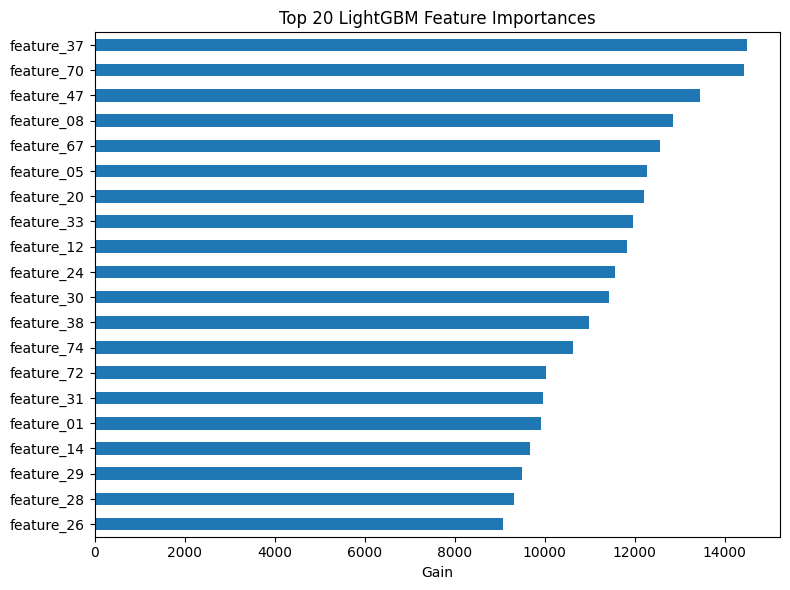

In [15]:
importance = pd.DataFrame(
    {
        "feature": feature_cols,
        "importance_gain": model.booster_.feature_importance(importance_type="gain"),
        "importance_split": model.booster_.feature_importance(importance_type="split"),
    }
).sort_values("importance_gain", ascending=False)

display(importance.head(20))

ax = importance.head(20).sort_values("importance_gain").plot.barh(
    x="feature",
    y="importance_gain",
    figsize=(8, 6),
    legend=False,
)
ax.set_title("Top 20 LightGBM Feature Importances")
ax.set_xlabel("Gain")
ax.set_ylabel("")
plt.tight_layout()

## Optional Local Result Save

The cell below writes only to `../data/local_results/`, which is ignored by Git because `data/` is ignored.

In [14]:
SAVE_LOCAL_RESULTS = False

if SAVE_LOCAL_RESULTS:
    results_dir = DATA_DIR / "local_results"
    results_dir.mkdir(parents=True, exist_ok=True)

    pd.DataFrame(
        {
            "y_true": y_test,
            "prediction": pred_test,
            "weight": w_test,
        }
    ).to_parquet(results_dir / "partition_9_small_sample_predictions.parquet", index=False)

    importance.to_csv(results_dir / "partition_8_9_lgbm_feature_importance.csv", index=False)
    print(f"Saved local results to {results_dir.resolve()}")
else:
    print("Local result saving is disabled.")

del train, test
gc.collect()

Local result saving is disabled.


84